# Nearest Neighbor Classifier on CIFAR-10

This is the classic baseline classifier from Stanford's CS231n course.

It does **not** use any deep learning — it just:
1. **Memorizes** every training image (`train`)
2. For every test image, finds the **single most similar** training image by raw pixel distance, and copies its label (`predict`)

**Why build this at all?** It's a rock-bottom baseline that reveals two core problems every later algorithm (KNN → Linear Classifiers → CNNs) is designed to fix:
- Prediction is painfully slow (has to scan the whole training set every time)
- Raw pixel distance is a poor measure of "similarity" between images


## 1. Imports

In [1]:
import numpy as np
import pickle
import os
import urllib.request
import tarfile
import matplotlib.pyplot as plt


## 2. Download and load CIFAR-10

This downloads the official CIFAR-10 python batches (~170MB) the first time you run it.

In [2]:
def download_cifar10(data_dir="./cifar10_data"):
    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    tar_path = os.path.join(data_dir, "cifar-10-python.tar.gz")
    extracted_dir = os.path.join(data_dir, "cifar-10-batches-py")

    if os.path.exists(extracted_dir):
        return extracted_dir

    os.makedirs(data_dir, exist_ok=True)
    print("Downloading CIFAR-10 (~170MB)...")
    urllib.request.urlretrieve(url, tar_path)

    print("Extracting...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(data_dir)

    return extracted_dir


def load_cifar_batch(filename):
    with open(filename, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
        images = batch[b"data"]                     # shape: (10000, 3072)
        labels = batch[b"labels"]
        images = images.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC
        return images, np.array(labels)


def load_cifar10(data_dir="./cifar10_data"):
    folder = download_cifar10(data_dir)

    xs, ys = [], []
    for i in range(1, 6):
        x, y = load_cifar_batch(os.path.join(folder, f"data_batch_{i}"))
        xs.append(x)
        ys.append(y)
    X_train = np.concatenate(xs)
    y_train = np.concatenate(ys)

    X_test, y_test = load_cifar_batch(os.path.join(folder, "test_batch"))

    return X_train, y_train, X_test, y_test


In [3]:
X_train, y_train, X_test, y_test = load_cifar10()
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Extracting...


/tmp/ipykernel_481413/738821448.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


X_train: (50000, 32, 32, 3)
y_train: (50000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)


## 3. Peek at a few images

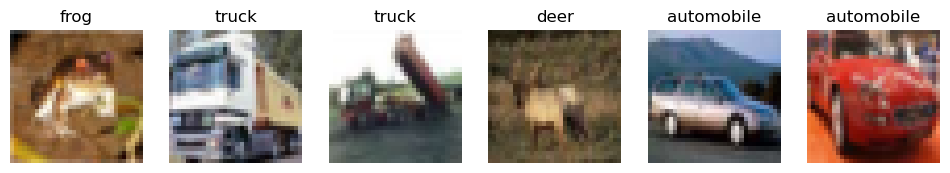

In [4]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")
plt.show()


## 4. The Nearest Neighbor Classifier

- `train()` just stores the data → **O(1)**, no real computation ("Machine learning!")
- `predict()` compares each test image against **every** training image → **O(N)**, the expensive part


In [5]:
class NearestNeighbor:
    def __init__(self):
        self.Xtr = None
        self.ytr = None

    def train(self, images, labels):
        """Memorize all data and labels."""
        self.Xtr = images
        self.ytr = labels

    def predict(self, test_images, distance="L1"):
        """Predict the label of the most similar training image."""
        num_test = test_images.shape[0]
        y_pred = np.zeros(num_test, dtype=self.ytr.dtype)

        Xtr_flat = self.Xtr.reshape(self.Xtr.shape[0], -1).astype(np.float64)

        for i in range(num_test):
            test_vec = test_images[i].reshape(-1).astype(np.float64)

            if distance == "L1":
                distances = np.sum(np.abs(Xtr_flat - test_vec), axis=1)
            elif distance == "L2":
                distances = np.sqrt(np.sum((Xtr_flat - test_vec) ** 2, axis=1))
            else:
                raise ValueError("distance must be 'L1' or 'L2'")

            nearest_index = np.argmin(distances)
            y_pred[i] = self.ytr[nearest_index]

            if (i + 1) % 50 == 0:
                print(f"  predicted {i + 1}/{num_test} test images...")

        return y_pred


## 5. Run it end-to-end

Using a small subset (5000 train / 200 test) to keep runtime reasonable in pure numpy —
this slowness is itself the point being demonstrated.


In [6]:
N_TRAIN = 5000
N_TEST = 200

X_train_sub, y_train_sub = X_train[:N_TRAIN], y_train[:N_TRAIN]
X_test_sub, y_test_sub = X_test[:N_TEST], y_test[:N_TEST]

nn = NearestNeighbor()

print("Training (memorizing data)...")
nn.train(X_train_sub, y_train_sub)   # instant

print("Predicting (comparing every test image against all training images)...")
y_pred = nn.predict(X_test_sub, distance="L1")   # slow


Training (memorizing data)...
Predicting (comparing every test image against all training images)...
  predicted 50/200 test images...
  predicted 100/200 test images...
  predicted 150/200 test images...
  predicted 200/200 test images...


In [7]:
accuracy = np.mean(y_pred == y_test_sub)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 29.00%


## 6. Visually inspect some predictions

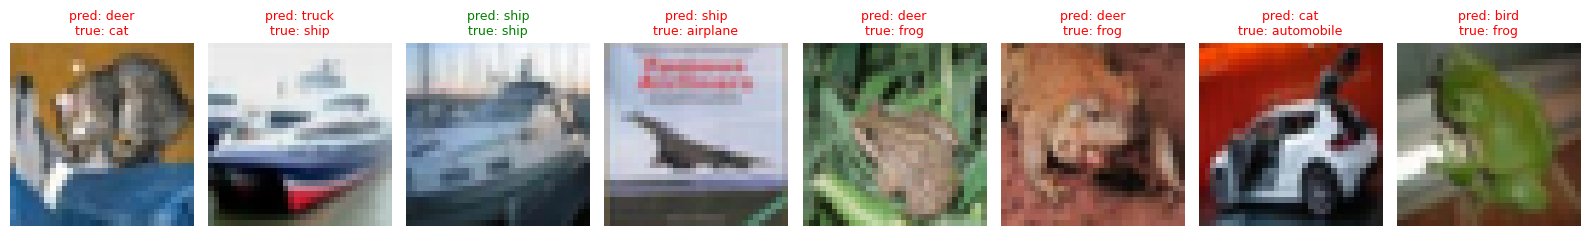

In [8]:
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test_sub[i])
    correct = y_pred[i] == y_test_sub[i]
    color = "green" if correct else "red"
    ax.set_title(f"pred: {class_names[y_pred[i]]}\ntrue: {class_names[y_test_sub[i]]}",
                 color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Why this matters — the motive behind it

1. **It's a floor, not a ceiling.** Before building a CNN, you need a dumb baseline to know if your "smart" model is actually learning anything.

2. **It exposes the train/predict tradeoff problem.** `train()` is instant, `predict()` is painfully slow — it scans the *entire* training set for every single prediction. Real-world systems want the opposite: slow, offline training and fast, real-time inference. This motivates shifting the heavy computation into training (as linear classifiers and CNNs do).

3. **It proves raw pixel distance is a bad similarity measure.** Two images of the same cat — one shifted a few pixels, or slightly brighter — can have a huge L1/L2 distance, while an unrelated image with a similar-colored background might look "closer." This motivates learning actual *features* (edges, textures, shapes) instead of comparing raw pixels — exactly what convolutional filters do.

4. **It's the simplest possible classifier**, making it the cleanest way to introduce core ML vocabulary (train set, test set, distance metric, accuracy) before adding complexity like gradients, loss functions, or backpropagation.

So the "motive" isn't that anyone deploys Nearest Neighbor in production — it's a teaching tool that sets a baseline and reveals exactly the two problems (speed, and meaningless pixel comparison) that every later algorithm in the course is built to solve.


## 8. Visualizing the decision surface

CIFAR-10 images live in 3072 dimensions (32×32×3 pixels), so we can't plot
the raw decision boundary directly. To actually *see* how Nearest Neighbor
carves up space, we first reduce the images to 2 dimensions with **PCA**,
then draw the decision surface in that 2D space — this is the same trick
used in CS231n-style demos.

Each colored region below shows what class label Nearest Neighbor would
assign to *any* point in that region. Because NN just copies the label of
whichever training point is closest, the boundaries between colors are
literally the perpendicular bisectors between neighboring training points
— giving the surface its jagged, cell-like look (this is called a
**Voronoi diagram**).

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

# To keep the plot readable, use a handful of classes and a small
# number of points per class rather than the full 10-class, 5000-point set.
DS_CLASSES = [0, 1, 3, 5, 8]   # airplane, automobile, cat, dog, ship
POINTS_PER_CLASS = 40

ds_X, ds_y = [], []
for c in DS_CLASSES:
    idx = np.where(y_train_sub == c)[0][:POINTS_PER_CLASS]
    ds_X.append(X_train_sub[idx])
    ds_y.append(y_train_sub[idx])

ds_X = np.concatenate(ds_X)                      # shape: (N, 32, 32, 3)
ds_y = np.concatenate(ds_y)                       # shape: (N,)
ds_X_flat = ds_X.reshape(ds_X.shape[0], -1)       # flatten to (N, 3072)

# Reduce 3072 pixel dimensions down to 2, purely for visualization
pca = PCA(n_components=2, random_state=0)
ds_X_2d = pca.fit_transform(ds_X_flat)

print(f"Reduced {ds_X_flat.shape[1]} pixel dimensions down to 2 for plotting")
print(f"Points plotted: {ds_X_2d.shape[0]} (from {len(DS_CLASSES)} classes)")


In [ ]:
# Fit Nearest Neighbor directly in the 2D PCA space
nn_2d = NearestNeighbor()
nn_2d.train(ds_X_2d, ds_y)

# Build a fine grid covering the 2D space
pad = 5.0
x_min, x_max = ds_X_2d[:, 0].min() - pad, ds_X_2d[:, 0].max() + pad
y_min, y_max = ds_X_2d[:, 1].min() - pad, ds_X_2d[:, 1].max() + pad

GRID_STEP = 1.0   # smaller = smoother boundary but slower to compute
xx, yy = np.meshgrid(np.arange(x_min, x_max, GRID_STEP),
                      np.arange(y_min, y_max, GRID_STEP))
grid_points = np.c_[xx.ravel(), yy.ravel()]

print(f"Predicting labels for {grid_points.shape[0]} grid points "
      f"(this is the expensive O(N) step, same as before)...")
grid_preds = nn_2d.predict(grid_points, distance="L2")
grid_preds = grid_preds.reshape(xx.shape)


In [ ]:
# Plot the decision surface with the training points overlaid
fig, ax = plt.subplots(figsize=(8, 7))

cmap_bg = plt.cm.get_cmap("tab10")
ax.contourf(xx, yy, grid_preds, alpha=0.35, cmap=cmap_bg,
            levels=np.arange(10 + 1) - 0.5)

scatter = ax.scatter(ds_X_2d[:, 0], ds_X_2d[:, 1], c=ds_y,
                      cmap=cmap_bg, edgecolor="black", s=60, vmin=0, vmax=9)

# Build a legend showing which color maps to which class
handles = [plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=cmap_bg(c / 9), markeredgecolor="black",
                       markersize=9, label=class_names[c])
           for c in DS_CLASSES]
ax.legend(handles=handles, loc="upper right", title="Class")

ax.set_title("Nearest Neighbor decision surface (2D PCA projection of CIFAR-10)")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
plt.tight_layout()
plt.show()


**What this shows:**

- Each dot is a real training image, projected down to 2D and colored by its true class.
- The background color at any point is whichever class label Nearest Neighbor would predict for a point *there* — found by checking which training dot is closest.
- Notice the boundaries are jagged, angular cell walls, not smooth curves — this is the Voronoi structure created by "always copy the nearest point's label." It also visually explains why NN is sensitive to outliers: a single mislabeled or unusual point can carve out its own little region of misclassified space around it.
- This is also a 2D stand-in for a 3072-dimensional problem — PCA necessarily discards information to make this plottable, so the real decision boundary in full pixel space is far messier than what's shown here. Treat this as intuition-building, not a literal picture of the true boundary.